## Clean & Combine

Joins the three raw hourly files on `datetime`, handles missing values, removes outliers, and saves a single clean dataset.

| File | Columns |
|---|---|
| `caiso_hourly.csv` | `load_mw` |
| `weather_hourly.csv` | `temperature_c`, `precipitation_mm`, `solar_radiation_wm2`, `windspeed_ms`, `humidity_pct` |
| `economic_hourly.csv` | `gas_price_mmbtu`, `is_holiday`, `is_weekend`, `hour_of_day`, `day_of_week`, `month` |

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RAW = '../../data/raw'
OUT = '../../data/processed/combined_hourly.csv'
os.makedirs(os.path.dirname(OUT), exist_ok=True)

# Columns to apply outlier detection on (skip binary/calendar columns)
CONTINUOUS = ['load_mw', 'temperature_c', 'precipitation_mm',
              'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu']

### 1. Load & align datetimes

CAISO and economic files are tz-aware (`-08:00`); weather is tz-naive. We convert everything to Pacific time then strip the tz so all three join cleanly on a naive index.

In [45]:
def load(path, dt_col='datetime'):
    df = pd.read_csv(path)   # read raw — no parse_dates
    raw = df[dt_col].astype(str)
    # Detect tz-aware strings (e.g. "2019-01-01 00:00:00-08:00")
    if raw.str.contains(r'[+-]\d{2}:\d{2}$', regex=True).any():
        dt = pd.to_datetime(raw, utc=True).dt.tz_convert('America/Los_Angeles').dt.tz_localize(None)
    else:
        dt = pd.to_datetime(raw)
    df[dt_col] = dt
    return df.set_index(dt_col).sort_index()

caiso   = load(f'{RAW}/caiso_hourly.csv')
weather = load(f'{RAW}/weather_hourly.csv')
econ    = load(f'{RAW}/economic_hourly.csv')

for name, d in [('caiso', caiso), ('weather', weather), ('econ', econ)]:
    print(f'{name:<8} {d.shape}  {d.index[0]}  →  {d.index[-1]}')

caiso    (52607, 1)  2019-01-01 00:00:00  →  2024-12-31 23:00:00
weather  (52608, 5)  2019-01-01 00:00:00  →  2024-12-31 23:00:00
econ     (52608, 6)  2019-01-01 00:00:00  →  2024-12-31 23:00:00


### 2. Merge

In [46]:
df = caiso.join(weather, how='inner').join(econ, how='inner')
print(f'Combined: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Range:    {df.index[0]}  →  {df.index[-1]}')
df.head(3)

Combined: 52,619 rows × 12 columns
Range:    2019-01-01 00:00:00  →  2024-12-31 23:00:00


,load_mw,temperature_c,precipitation_mm,solar_radiation_wm2,windspeed_ms,humidity_pct,gas_price_mmbtu,is_holiday,is_weekend,hour_of_day,day_of_week,month
datetime,,,,,,,,,,,,
2019-01-01 00:00:00,21934,4.525,0.0,0.0,3.6525,57.50,NaN,0,0,0,1,1
2019-01-01 01:00:00,21188,4.475,0.0,0.0,3.1250,56.50,NaN,0,0,1,1,1
2019-01-01 02:00:00,20613,3.475,0.0,0.0,3.1950,57.25,NaN,0,0,2,1,1


### 3. Missing values

In [47]:
missing = df.isnull().mean() * 100
print('Missing % per column:')
print(missing.round(2).to_string())

Missing % per column:
load_mw                0.00
temperature_c          0.00
precipitation_mm       0.00
solar_radiation_wm2    0.00
windspeed_ms           0.00
humidity_pct           0.00
gas_price_mmbtu        4.06
is_holiday             0.00
is_weekend             0.00
hour_of_day            0.00
day_of_week            0.00
month                  0.00


### 4. Outlier detection (IQR) → replace with NaN

In [48]:
def flag_outliers(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        # Zero-inflated column (e.g. precipitation) — skip IQR, it would flag all non-zero values
        return pd.Series(False, index=series.index)
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)

for col in CONTINUOUS:
    mask = flag_outliers(df[col])
    n = int(mask.sum())
    df.loc[mask, col] = np.nan
    print(f'  {col:<25} {n:>5} outliers  ({n/len(df)*100:.2f}%)')

  load_mw                    3000 outliers  (5.70%)
  temperature_c               101 outliers  (0.19%)
  precipitation_mm              0 outliers  (0.00%)
  solar_radiation_wm2           0 outliers  (0.00%)
  windspeed_ms                900 outliers  (1.71%)
  humidity_pct                  0 outliers  (0.00%)
  gas_price_mmbtu            5160 outliers  (9.81%)


### 5. Interpolate & fill

In [49]:
# Time-based linear interpolation for short gaps (≤6 hours)\ndf[CONTINUOUS] = df[CONTINUOUS].interpolate(method='time', limit=6)\n\n# Forward-fill only — bfill would pull future values into past NaNs (leakage)\ndf[CONTINUOUS] = df[CONTINUOUS].ffill()\n\n# Any NaN still remaining at the very start of the series: fill with column median\nfor col in CONTINUOUS:\n    if df[col].isna().any():\n        df[col] = df[col].fillna(df[col].median())\n\nremaining = df.isnull().sum()\nprint('NaN remaining after fill:')\nprint(remaining[remaining > 0].to_string() if remaining.any() else '  None — dataset is complete')

### 6. EDA

In [50]:
df.describe().round(2)

,load_mw,temperature_c,precipitation_mm,solar_radiation_wm2,windspeed_ms,humidity_pct,gas_price_mmbtu,is_holiday,is_weekend,hour_of_day,day_of_week,month
count,49619.00,52518.00,52619.00,52619.00,51719.00,52619.00,45323.00,52619.0,52619.00,52619.00,52619.0,52619.00
mean,24449.73,17.32,0.06,218.48,2.43,60.11,2.76,0.0,0.29,11.50,3.0,6.52
std,3572.89,7.64,0.26,296.98,0.99,20.41,1.01,0.0,0.45,6.92,2.0,3.45
min,14853.00,-0.95,0.00,0.00,0.25,6.75,1.21,0.0,0.00,0.00,0.0,1.00
25%,21774.00,11.40,0.00,0.00,1.69,43.75,2.10,0.0,0.00,5.00,1.0,4.00
50%,24020.00,16.50,0.00,12.50,2.22,62.50,2.53,0.0,0.00,11.00,3.0,7.00
75%,26490.00,22.28,0.00,415.62,3.06,77.00,2.95,0.0,1.00,17.00,5.0,10.00
max,34868.00,38.65,4.72,1017.25,5.24,99.75,6.00,0.0,1.00,23.00,6.0,12.00


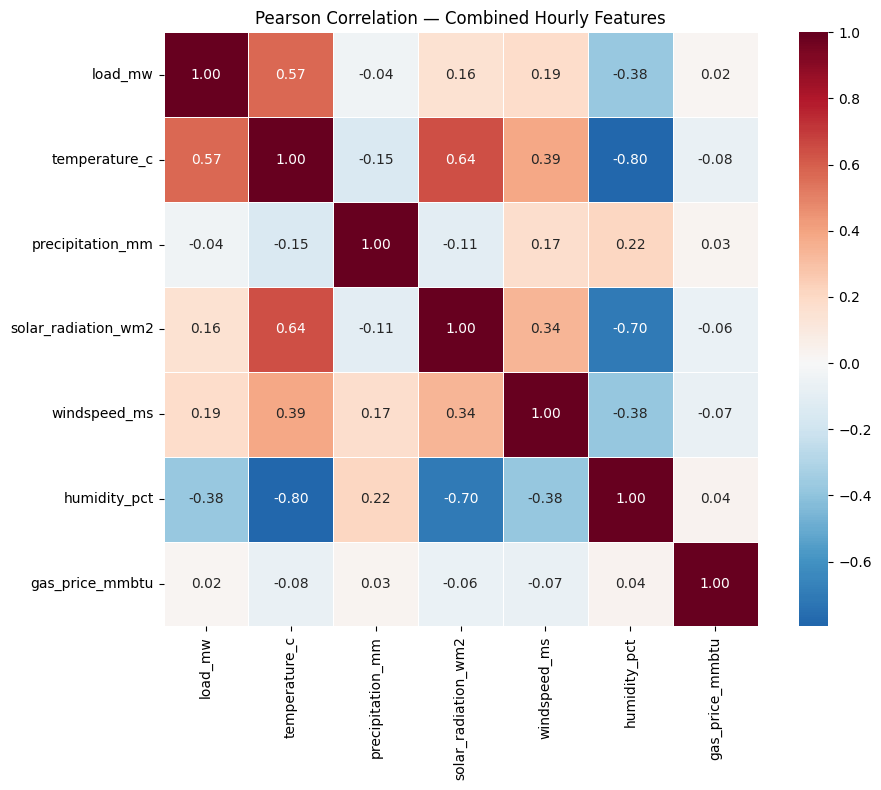

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[CONTINUOUS].corr(),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    square=True, linewidths=0.4, ax=ax
)
ax.set_title('Pearson Correlation — Combined Hourly Features')
plt.tight_layout()
plt.savefig('../../data/processed/correlation_heatmap.png', dpi=150)
plt.show()

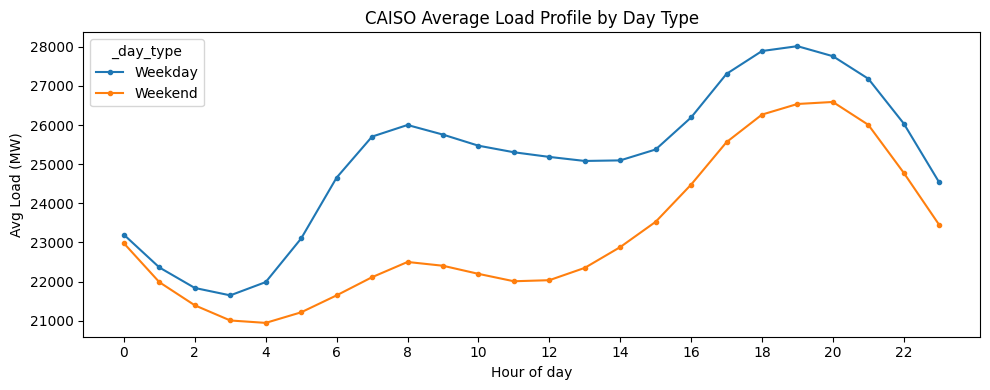

In [52]:
# Load profile by day type
df['_day_type'] = 'Weekday'
df.loc[df['is_weekend'] == 1, '_day_type'] = 'Weekend'
df.loc[df['is_holiday'] == 1, '_day_type'] = 'Holiday'

profile = df.groupby(['hour_of_day', '_day_type'])['load_mw'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 4))
profile.plot(ax=ax, marker='o', markersize=3)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg Load (MW)')
ax.set_title('CAISO Average Load Profile by Day Type')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig('../../data/processed/load_profiles.png', dpi=150)
plt.show()

df = df.drop(columns='_day_type')

### 7. Save (raw — standardisation happens in model notebooks on train split only)

In [53]:
df.to_csv(OUT)
print(f'Saved {len(df):,} rows × {len(df.columns)} columns → {OUT}')
print('Columns:', df.columns.tolist())

Saved 52,619 rows × 12 columns → ../../data/processed/combined_hourly.csv
Columns: ['load_mw', 'temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu', 'is_holiday', 'is_weekend', 'hour_of_day', 'day_of_week', 'month']
